In [1]:
# --- Setup: base imports ---
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import inspect
import html
from IPython.display import display, HTML

# --- Setup: project path ---
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Add Original_Programs folder itself because some files use sibling imports
ORIGINAL_ML_DIR = PROJECT_ROOT / "Legendre_Polynomials" / "Multi_Level" / "Original_Programs"
if str(ORIGINAL_ML_DIR) not in sys.path:
    sys.path.append(str(ORIGINAL_ML_DIR))

SINGLE_LEVEL_DIR = PROJECT_ROOT / "Legendre_Polynomials" / "Single_Level"
if str(SINGLE_LEVEL_DIR) not in sys.path:
    sys.path.append(str(SINGLE_LEVEL_DIR))

# --- Optional (recommended) for syntax highlighting ---
from pygments import highlight
from pygments.lexers import PythonLexer
from pygments.formatters import HtmlFormatter

_PYGMENTS_CSS_LOADED = False

def show_full_function(func, name=None):
    global _PYGMENTS_CSS_LOADED
    
    name = name or func.__name__
    source = inspect.getsource(func)

    formatter = HtmlFormatter(style="friendly", noclasses=False)
    highlighted = highlight(source, PythonLexer(), formatter)

    if not _PYGMENTS_CSS_LOADED:
        css = formatter.get_style_defs('.highlight')
        display(HTML(f"<style>{css}</style>"))
        _PYGMENTS_CSS_LOADED = True

    html_block = f"""
    <details>
      <summary><strong>View full function: {html.escape(name)}</strong></summary>
      {highlighted}
    </details>
    """
    display(HTML(html_block))

# --- Core ML utilities ---
from Legendre_Polynomials.Multi_Level.Original_Programs.ML_level_utilities import (
    GBM_paths,
    tot_degree_poly,
    normaleq_components_ML,
    fit_local_vol,
    make_b_bar,
)

# --- Standard telescoping-sum MLMC ---
from Legendre_Polynomials.Multi_Level.Original_Programs.ML_telescoping_sum import (
    scalings_l0,
    mlmc_l,
    make_c,
)

# --- Weak error analysis ---
from Legendre_Polynomials.Multi_Level.Original_Programs.ML_weak_error_analysis import (
    compute_weak_error_ML,
    plot_weak_error_convergence,
)

from Legendre_Polynomials.Single_Level.SL_surface_visualisation import plot_local_volatility

<h1 style="text-align: left; color: #0B63CE;">What this Notebook will do</h1>

This notebook integrates the whole `Multi_Level/Original_Programs` workflow of the `Legendre` folder:

1. build the Legendre regression model from `ML_level_utilities.py`,
2. Construct the standar telescopic sum,
3. visualize the local volatility surface,
4. study weak error convergence for option pricing.

<h1 style="text-align: center;">Multi-Level Markovian Projection with Legendre Polynomial Regression</h1>

## Black-Scholes Correlated Model:
We consider a $d$-dimensional correlated Black--Scholes model
\begin{align}
dX(t)&=a(t,X(t))\,dt+b(t,X(t))\,dW(t),
\qquad 0\le t\le T,
\qquad X(t)\in\mathbb{R}^d,\\
X(0)&=x_0.
\end{align}
where
- $W(t)$ is a $k$-dim. Brownian motion.
- $a(t,x)=r\,x,\qquad r=0.05.$  
- $b(t,x)\in\mathbb{R}^{d\times k}.$  
- $(b_{\mathrm{BS}}(t,x))_{ij}=x_i\,\Sigma_{ij}.$

### Example ($d=3, k=3$)

Let $x=(x_1,x_2,x_3)^\top$ and $\sigma=(\sigma_1,\sigma_2,\sigma_3)^\top$. Assume the correlated Black–Scholes diffusion is defined by
$$
b_{\mathrm{BS}}(t,x)=\mathrm{diag}(x)\,\mathrm{diag}(\sigma)\,G, \quad \text{equivalently}\;\;\bigl(b_{\mathrm{BS}}(t,x)\bigr)_{ij}=\sigma_i x_i\,G_{ij}
$$
where,
$$
\Sigma_{ij}=\sigma_i\,G_{ij}, \qquad 
GG^\top=
\begin{pmatrix}
1 & 0.8 & 0.3\\
0.8 & 1 & 0.1\\
0.3 & 0.1 & 1
\end{pmatrix},
\qquad
\sigma=(0.2,\ 0.15,\ 0.1)^\top.
$$
Each component satisfies
$$
dX_i(t)=rX_i(t)\,dt+\sigma_iX_i(t)\sum_{j=1}^{k}G_{ij}\,dW_j(t),
\qquad i=1,\dots,d.
$$
Thus, even if the Brownian motions $W_1,\dots,W_k$ are independent, the assets are correlated through the matrix $G$.

## Markovian Projection
Let $S(t)=P_1 X(t)$, with $P_1\in\mathbb{R}^{1\times d}$ and $X(t)\in\mathbb{R}^{d\times 1}$. Define the Markovian surrogate $\bar S^{(x_0)}(t)$ by
$$
\left\{
\begin{aligned}
d\bar S^{(x_0)}(t) &= \bar a^{(x_0)}\!\bigl(t,\bar S^{(x_0)}(t)\bigr)\,dt
+ \bar b^{(x_0)}\!\bigl(t,\bar S^{(x_0)}(t)\bigr)\,d\bar W(t), \qquad t\in[0,T],\\
\bar S^{(x_0)}(0) &= P_1 x_0.
\end{aligned}
\right.
$$

The drift and diffusion coefficients are given by conditional expectations:
$$
\bar a^{(x_0)}(t,s)
=\mathbb{E}\!\left[\,P_1 a\!\bigl(t,X(t)\bigr)\ \middle|\ P_1 X(t)=s,\ X(0)=x_0\,\right]
=\mathbb{E}\!\left[\,r\,P_1 X(t)\ \middle|\ P_1 X(t)=s,\ X(0)=x_0\,\right]
= r\,s,
$$
and
$$
\bigl(\bar b^{(x_0)}(t,s)\bigr)^2
=\mathbb{E}\!\left[\,P_1 b_{\text{BS}}\!\bigl(t,X(t)\bigr)\,b_{\text{BS}}\!\bigl(t,X(t)\bigr)^\top P_1^\top\ \middle|\ P_1 X(t)=s,\ X(0)=x_0\,\right].
$$
For $P_1=\frac{1}{d}(1,\ldots,1)$ and $C=GG^\top$, this becomes
$$
\bigl(\bar b^{x_0}(t,s)\bigr)^2
=
\mathbb{E}\!\left[
\frac{1}{d^2}\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,X_i(t)\,X_j(t)\,C_{ij}
\ \middle|\ P_1 X(t)=s,\ X(0)=x_0
\right],
$$

## $L^2$ Regression Problem

We approximate $\big(\bar b^{x_0}\big)^2(\cdot,\cdot)$ by solving the time-integrated $L^2$ problem
$$
\big(\bar b^{x_0}\big)^2(\cdot,\cdot)
\approx
\arg\min_{h\in V}\ 
\int_{0}^{T}
\mathbb{E}\!\left[
\left(
P\,b_{\text{BS}}\!\bigl(t,X(t)\bigr)\,b_{\text{BS}}\!\bigl(t,X(t)\bigr)^\top P^\top
- h\!\bigl(t,PX(t)\bigr)
\right)^2
\ \middle|\ X(0)=x_0
\right]dt.
$$

For example, one may choose a parametric class
$$
V=\{\,h:\ h(t,x)=c_0+c_1 t+c_2 x\,\}.
$$
Discretizing time with a grid $0=t_0<t_1<\cdots<t_N=T$, an empirical Monte Carlo objective is
$$
\big(\bar b^{x_0}\big)^2(\cdot,\cdot)
\approx
\arg\min_{h\in V}\ 
\frac{1}{M}\sum_{m=1}^{M}\ \frac{1}{N}\sum_{n=1}^{N}
\left(
\frac{1}{d^2}\sum_{i=1}^{d}\sum_{j=1}^{d}
\sigma_i\sigma_j\,X_i^{(m)}(t_n)\,X_j^{(m)}(t_n)\,C_{ij}
- h\!\bigl(t_n,PX^{(m)}(t_n)\bigr)
\right)^2.
$$

**Ansatz.** We approximate the squared projected diffusion by a finite expansion
$$
\tilde b^2(t,s)\approx \sum_{p=1}^{P} c_p\,\psi_p(t,s).
$$


<details>
<summary><strong>Discrete $L^2$ Projection</strong></summary>

Let $y \in \Gamma \subset \mathbb{R}^N$ be a random parameter with density $\rho$, and let

$$
u : \Gamma \to V
$$

be the solution map, where $V$ is a Hilbert space. For each realization $y$, one solves a deterministic problem, so $u(y)$ is the corresponding solution. Since $y$ is random, the natural error measure is the mean-square norm

$$
\|u\|_{L^2_\rho(\Gamma;V)}^2
=
\int_\Gamma \|u(y)\|_V^2 \rho(y)\,dy.
$$


### Discrete $L^2$ projection (Random PDE context)

We choose a finite-dimensional polynomial space with basis $\{\psi_p\}_{p\in\Lambda}$, where $\Lambda$ is a finite index set. Then we approximate $u$ in the space

$$
\mathbb{P}_\Lambda(\Gamma)\otimes V
=
\left\{
v(y)=\sum_{p\in\Lambda} \hat v_p \psi_p(y), \quad \hat v_p \in V
\right\}.
$$

Here, the coefficients $\hat v_p$ belong to $V$, while the dependence on $y$ is described by polynomials. The best approximation is the $L^2_\rho$-projection of $u$ onto this space:

$$
\Pi_\Lambda u
=
\arg\min_{v\in \mathbb{P}_\Lambda(\Gamma)\otimes V}
\|u-v\|_{L^2_\rho(\Gamma;V)}^2.
$$

This means that $\Pi_\Lambda u$ is the best polynomial approximation of $u$ in the mean-square sense.

If the basis is orthonormal, then

$$
\Pi_\Lambda u(y)
=
\sum_{p\in\Lambda} \hat u_p \psi_p(y),
\qquad
\hat u_p = \mathbb{E}[u(y)\psi_p(y)].
$$

### Transition to the discrete formulation

The previous projection is well defined, but in practice it cannot usually be computed exactly, because it involves expectations such as

$$
\mathbb{E}[u(y)\psi_p(y)].
$$

In applications, $u(y)$ is not known in closed form. Instead, one evaluates it at sampled points

$$
y^{(1)}, \dots, y^{(M)},
$$

and obtains the corresponding snapshots

$$
u^{(k)} = u(y^{(k)}), \qquad k=1,\dots,M.
$$

This leads to a computable approximation of the $L^2$-projection.

### $L^2$ discrete projection

We replace the exact $L^2_\rho$-norm by the empirical norm

$$
\|g\|_M^2
=
\frac{1}{M}\sum_{k=1}^M \|g(y^{(k)})\|_V^2.
$$

Then the discrete projection is defined by

$$
\widehat{\Pi}_{\Lambda,M}u
=
\arg\min_{v\in \mathbb{P}_\Lambda(\Gamma)\otimes V}
\frac{1}{M}\sum_{k=1}^M \|u^{(k)} - v(y^{(k)})\|_V^2.
$$

Thus, the exact projection

$$
\Pi_\Lambda u
=
\arg\min \|u-v\|_{L^2_\rho(\Gamma;V)}^2
$$

is replaced by the computable discrete projection

$$
\widehat{\Pi}_{\Lambda,M}u
=
\arg\min \|u-v\|_M^2.
$$

### Algebraic form

Write the approximation as

$$
v(y)=\sum_{p\in\Lambda} c_p \psi_p(y).
$$

Evaluating at the sample points gives

$$
v(y^{(k)})=\sum_{p\in\Lambda} c_p \psi_p(y^{(k)}).
$$

Define the design matrix $D$ by

$$
D_{k,p} = \psi_p(y^{(k)}),
\qquad
k=1,\dots,M,\quad p\in\Lambda.
$$

Then the coefficients $c=(c_p)_{p\in\Lambda}$ are obtained from the least-squares problem, which leads to the normal equations

$$
D^T D\,c = D^T U,
$$

where $U$ collects the sampled values $u^{(k)}$.

Therefore, the discrete $L^2$-projection becomes a standard least-squares regression problem.
</details>

<details>
<summary><strong> Multi-Level discrete $L^2$ Projection</strong></summary>
Assume that the target quantity depends on a parameter $y \in \Gamma$, and let

$$
f_{n_{\ell}} : \Gamma \to \mathbb{R}, \qquad \ell=0,1,\dots,L,
$$

be a hierarchy of numerical approximations of a target function $f$. Here, the index $n_{\ell}$ refers to the **solver discretization level**, for example a time step or mesh refinement. Thus, for each fixed $y$, the quantity $f_{n_{\ell}(y)}$ is the approximation produced by the level-$\ell$ solver.

We assume that

$$
\|f-f_{n_{\ell}}\|_{L^2_\mu(\Gamma)} \to 0
\qquad \text{as } \ell\to\infty,
$$

that is, the numerical approximations converge to $f$ in mean square over the parameter space $\Gamma$.

The key identity is the telescoping decomposition

$$
f_{n_L} = f_0 + \sum_{\ell=1}^L \bigl(f_{n_{\ell}}-f_{n_{\ell}-1}\bigr).
$$

Instead of approximating $f_L$ directly by a single least-squares fit, the multilevel idea is to approximate each correction separately.

Similarly, we introduce 
$$
\Lambda_{m_0}\subset \Lambda_{m_1} \subset \ldots \subset \Lambda_{m_k}\ldots 
$$
such that 
$$\lim_{k\to\infty} \inf_{v\in V_{\Lambda_{m_k}}} \|f-v\|_{L^2_\mu} = 0$$

For each $\Lambda_{m_k}$ we introduce a weighted discrete least square projection operator $\widehat{\Pi}_{M_k}$ using $O(|\Lambda_{m_k}|)$ random points. Given a maximum level $L\in \mathbb{N}$:

$$
S_L(f)
=
\widehat{\Pi}_L(f_0)
+
\sum_{\ell=1}^L \widehat{\Pi}_{L-\ell}\bigl(f_\ell-f_{\ell-1}\bigr).
$$

</details>

<h1 style="text-align: center;">$L^2$ Projection SDES</h1>
Recall:

$$
\big(\bar b^{x_0}\big)^2 \approx \arg\min_{h\in V}\ \frac{1}{M}\sum_m \frac{1}{N}\sum_n
\left(
P_1^{T} b(t_n,X^m(t_n))\,b(t_n,X^m(t_n))^{T}P_1
-
h\bigl(t_n,P_1 X^m(t_n)\bigr)
\right)^2
$$

where $X^m$ are independent realizations of $X$. Denote

$$
g := P_1^{T} b(t,X(t))\,b(t,X(t))^{T}P_1.
$$

$$
S_L(f) := \Pi_{V_L} g_0(X_0) + \sum_{\ell=1}^{L} \Pi_{V_{L-\ell}}\bigl(g(X^\ell)-g(X^{\ell-1})\bigr)
$$

where

$$
\Pi_{V_{L-\ell}}\bigl(g(X^\ell)-g(X^{\ell-1})\bigr)
=
\arg\min_{v\in V_{L-\ell}}
\left\|
\bigl(g(X^\ell)-g(X^{\ell-1})\bigr)-v(\cdot)
\right\|.
$$

Compute the projection of correction $\Pi_{V_{L-\ell}}\bigl(g(X^\ell)-g(X^{\ell-1})\bigr)$ by 
    \begin{align}
\arg\min_{h\in V}
\frac{1}{M_\ell}&\sum_{m=1}^{M_\ell}\frac{1}{N_{\ell-1}}\sum_{n=1}^{\mathbf{{\color{green}{N_{\ell-1}}}}}
\Biggl(
{\color{blue}{\Bigl[
P^\top b\!\bigl(t_n,X_\ell^m(t_n^{\ell-1})\bigr)\,
b\!\bigl(t_n,X_\ell^m(t_n^{\ell-1})\bigr)^\top P
\notag}}\\
&
-
{\color{blue}{P^\top b\!\bigl(t_n,X_{\ell-1}^m(t_n^{\ell-1})\bigr)\,
b\!\bigl(t_n,X_{\ell-1}^m(t_n^{\ell-1})\bigr)^\top P
\Bigr]}}
-
{\color{red}{h\!\bigl(t_n^{\ell-1},PX_\ell^m(t_n^{\ell-1})\bigr)}}
\Biggr)^2
\end{align}
\begin{equation}
    {\color{red}{D \in \mathbb{R}^{M_{\ell}N_{\ell-1}\times |\Lambda|}}}, {\color{blue}{\Psi \in \mathbb{R}^{M_{\ell}N_{\ell-1}}}}, c_{\ell}\in \mathbb{R}^{|\Lambda_{L-\ell}|}
\end{equation}
\begin{equation}
    M_{\ell}=C\times \text{dim}(V_{L-\ell})^2, \quad V_{L-\ell}
=
\operatorname{span}\Bigl\{
\widetilde P_i(\tau(t))\widetilde P_j(\xi(s))
:\ i+j\le L-\ell
\Bigr\}.
\end{equation}
 The estimated coefficient is
\begin{equation}
   (\bar{b}^{x_0})^2(t,s)\approx \sum_{p\in \Lambda_L}c_p \psi(t,s), \quad  c = \{c_p\}_{p\in \Lambda_L}=\sum_{\ell=0}^Lc_{\ell}
\end{equation}

 -  Assume that there exists $\theta_{\Delta t} : X^\ell \to X^{\ell-1}$ such that $X^{\ell-1}\to X^\ell$ as $\Delta t \to 0$.

$$
\Rightarrow\ 
\Pi_{V_{L-\ell}}\bigl(g(X^\ell)-g(X^{\ell-1})\bigr)
:=
\arg\min_{v\in V_{L-\ell}}
\left\|
\bigl(g(X^\ell)-g(\theta_{\Delta t}(X^\ell))\bigr)-v(X^\ell)
\right\|.
$$
This map will depend on the particular path in question: $\theta_{\Delta t}(X^\ell,\omega)$.  

-  Consider a sequence of exponentially increasing polynomial subspaces $(V_\ell)_{\ell=0}^{\infty}$: we choose subspaces of (total degree) Legendre polynomials which are orthogonal on $[-1,1]$ with weight function $w=1$.

-  Exponentially decreasing time steps $h_0,h_1,\ldots,h_\ell,\ldots$: we choose

$$
h_\ell \approx h_0\,2^{-\ell}.
$$

<h1 style="text-align: center;">Implementation</h1>

<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 1: Define the multi-level setting and estimate the basket scaling domain
</h4>
<details>

In this first implementation step, we initialize the market parameters, define the multi-level hierarchy, and estimate the basket-value interval used for Legendre scaling.

The stochastic model is the same correlated Black--Scholes basket:
$$
dX_i(t)=rX_i(t)\,dt+\sigma_iX_i(t)\,(G\,dW(t))_i,
\qquad i=1,\dots,d,
$$
with equal-weight basket
$$
S(t)=P_1^\top X(t),
\qquad
P_1=\frac1d(1,\dots,1)^\top.
$$

The new ingredient is the **multi-level hierarchy of timesteps**
$$
h_l=h_0\,2^{-l},
\qquad l=0,1,\dots,L,
$$
where:
- $h_0$ is the coarsest timestep,
- $L$ is the finest level.

In this implementation, the maximum polynomial degree and the number of levels are tied together: the finest level corresponds to `max_deg`, and this determines the pilot discretization used to estimate the basket domain.

Before building the level-wise regression systems, we need a stable spatial interval
$$
[s_{\min},\,s_{\max}]
$$
for the basket variable. This is required because the Legendre basis will later be evaluated on the scaled interval $[-1,1]$ through
$$
\xi(s)=\frac{2(s-s_{\min})}{s_{\max}-s_{\min}}-1.
$$

### Function used: `GBM_paths`

**Syntax**
```python
paths = GBM_paths(x0, r, vol, cov_mat, dt, N_t, M_t)
```

**What it does**
- Simulates correlated $d$-dimensional geometric Brownian motion paths.
- Uses the Cholesky factor of the correlation matrix to generate correlated Brownian increments.
- Returns the path array used for Monte Carlo training or pilot estimation.

In this step, `GBM_paths` is not called directly in the notebook cell, but it is used internally by `scalings_l0(...)`.

### Function used: `scalings_l0`

**Syntax**
```python
s_min0, s_max0, basket0 = scalings_l0(
    x0, T, h0, r, cov_mat, vol, max_deg, P1,
    M_0=10000, return_basket=True
)
```

**What it does**
- Runs a pilot simulation at the **finest timestep**
  $$
  h_{\mathrm{fine}}=h_0\,2^{-L},
  \qquad L=\texttt{max\_deg},
  $$
  so that the basket range is estimated on the most resolved grid.
- Computes empirical lower and upper percentile bounds of the basket values.
- Returns:
  - `s_min0`: lower basket bound,
  - `s_max0`: upper basket bound,
  - `basket0`: pilot basket paths.

These bounds define the spatial interval on which the Legendre approximation will be fitted.

### Mathematical role of this step

This step prepares the multi-level construction.

It fixes:
- the basket model,
- the coarsest time resolution $h_0$,
- the finest level $L$,
- and the basket scaling interval.

So before any telescoping correction is computed, we already have the global domain on which the level-wise Legendre approximations will be built.

</details>

In [2]:
# Step 1: define the multi-level setting and estimate the scaling domain

# Basket configuration
d = 3
P1 = np.ones(d) / d

# Market parameters
r = 0.05
x0 = np.linspace(225, 275, num=d)[:, np.newaxis]
vol = np.array([0.2, 0.15, 0.1])
cov_mat = np.array([
    [1.0, 0.8, 0.3],
    [0.8, 1.0, 0.1],
    [0.3, 0.1, 1.0]
])

# Time horizon and multi-level hierarchy
T = 1.0
h0 = 0.125          # coarsest timestep
max_deg = 2         # also determines finest level L = max_deg

# Pilot run for basket scaling domain
s_min0, s_max0, basket0 = scalings_l0(
    x0=x0,
    T=T,
    h0=h0,
    r=r,
    cov_mat=cov_mat,
    vol=vol,
    max_deg=max_deg,
    P1=P1,
    M_0=10000,
    return_basket=True
)

print("\n--- Step 1 summary ---")
print("d =", d)
print("P1 =", P1)
print("T =", T)
print("h0 =", h0)
print("max_deg =", max_deg)
print("number of ML levels =", max_deg + 1)
print("finest timestep =", h0 * 2**(-max_deg))
print("s_min0 =", s_min0)
print("s_max0 =", s_max0)
print("basket0 shape =", basket0.shape)


--- Step 1 summary ---
d = 3
P1 = [0.33333333 0.33333333 0.33333333]
T = 1.0
h0 = 0.125
max_deg = 2
number of ML levels = 3
finest timestep = 0.03125
s_min0 = 181.3723849923068
s_max0 = 380.76138551009706
basket0 shape = (10000, 32)


In [20]:
show_full_function(GBM_paths)

In [21]:
show_full_function(scalings_l0)

<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 2: Define the level-dependent polynomial spaces
</h4>
<details>
Before constructing any multi-level correction, we must understand how the approximation space changes from level to level.

In the standard multi-level implementation, the time discretization becomes finer as the level increases:
$$
h_l = h_0\,2^{-l},
\qquad l=0,1,\dots,L.
$$

At the same time, the polynomial approximation space is made **level-dependent**.

If the maximum polynomial degree is `max_deg`, then at level $l$ the implementation uses
$$
d_l = \texttt{max\_deg} - l.
$$

So:
- coarse levels use richer polynomial spaces,
- fine levels use smaller correction spaces.

This is natural in the multi-level setting, because finer levels are intended only to correct what is missing from the coarser approximation.

### Function used: `tot_degree_poly`

**Syntax**
```python
pairs_l = tot_degree_poly(deg_l)
```

**What it does**
- Generates the set of basis index pairs
  $$
  \Lambda_l=\{(i,j)\in\mathbb{N}_0^2:\ i+j\le d_l\},
  $$
  where $d_l$ is the polynomial degree used at level $l$.
- Each pair $(i,j)$ corresponds to the basis function
  $$
  \widetilde P_i(\tau(t))\,\widetilde P_j(\xi(s)).
  $$

### Why the degree decreases with the level

In the multi-level telescoping construction, level $0$ carries the main coarse approximation, while higher levels only provide corrections.

So the implementation uses:
- more basis functions on coarse levels,
- fewer basis functions on fine levels.

This keeps the cost under control while preserving the telescoping structure of the approximation.

### Mathematical role of this step

This step defines the level-wise approximation spaces
$$
V_l=\operatorname{span}\Big\{
\widetilde P_i(\tau(t))\,\widetilde P_j(\xi(s)):\ i+j\le d_l
\Big\}.
$$

The next step will use these spaces to build the actual level correction estimator.

</details>

In [3]:
# Step 2: inspect the level-dependent polynomial spaces

level_info = []

for l in range(max_deg + 1):
    deg_l = max_deg - l
    pairs_l = tot_degree_poly(deg_l)
    
    level_info.append((l, deg_l, len(pairs_l), pairs_l[:6]))
    
    print(f"Level l = {l}")
    print(f"  degree d_l = {deg_l}")
    print(f"  number of basis functions = {len(pairs_l)}")
    print(f"  first basis pairs = {pairs_l[:6]}")
    print()

Level l = 0
  degree d_l = 2
  number of basis functions = 6
  first basis pairs = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (2, 0)]

Level l = 1
  degree d_l = 1
  number of basis functions = 3
  first basis pairs = [(0, 0), (0, 1), (1, 0)]

Level l = 2
  degree d_l = 0
  number of basis functions = 1
  first basis pairs = [(0, 0)]



In [23]:
show_full_function(tot_degree_poly)

<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 3: Compute a single multi-level correction with <code>mlmc_l</code>
</h4>
<details>

This is the core step of the standard multi-level method.

At level $l$, the goal is not to fit the full projected variance directly.  
Instead, we fit a **correction** between a fine approximation and a coarse approximation.

If the fine timestep is
$$
h_l = h_0\,2^{-l},
$$
then the corresponding coarse timestep is
$$
h_{l-1}=2h_l.
$$

The multi-level idea is to approximate the level correction
$$
\bar b_l^2(t,s)-\bar b_{l-1}^2(t,s),
$$
and then sum these corrections across levels.

### Function used: `mlmc_l`

**Syntax**
```python
c_l = mlmc_l(x0, T, h0, l, r, cov_mat, vol, max_deg, P1, s_min0, s_max0, C=80)
```

**What it does**
- Builds the level-$l$ regression correction.
- Generates coupled fine and coarse paths.
- Constructs the regression system for the volatility difference.
- Solves the level-specific least-squares problem.
- Returns a padded coefficient vector `c_l` so that all levels can later be summed consistently.

### Step 3a: Fine/coarse coupling

The function generates:
- fine paths with timestep $h_l$,
- coarse paths with timestep $2h_l$.

The coupling is crucial: both levels use the **same underlying Gaussian randomness**, with the coarse increments obtained by summing consecutive fine increments.

This coupling is what reduces the variance of the level correction.

### Step 3b: Level-specific polynomial space

At level $l$, the code uses the degree
$$
d_l=\texttt{max\_deg}-l.
$$

So the correction is fitted in the space
$$
V_l
=
\operatorname{span}\Bigl\{
\widetilde P_i(\tau(t))\widetilde P_j(\xi(s))
:\ i+j\le d_l
\Bigr\}.
$$

This means coarse levels carry richer approximation spaces, while finer levels carry smaller correction spaces.

### Internal function used: `normaleq_components_ML`

Inside `mlmc_l(...)`, the coupled paths are passed to
```python
normaleq_components_ML(paths_f, paths_c, P1, pairs, cov_mat, vol, s_min0, s_max0, T)
```

This function builds:
- the design matrix $D_l$,
- and the target vector $\psi_l$,

where the target is now the **difference**
$$
\psi_l = b_{\mathrm{fine}}^2 - b_{\mathrm{coarse}}^2.
$$

This is the key mathematical difference from the single-level notebook, where the target was only $b^2$.

### Internal function used: `fit_local_vol`

Once the system
$$
D_l c_l \approx \psi_l
$$
is built, the coefficients are obtained by QR regression:
```python
c = fit_local_vol(D, psi)
```

So each level produces its own coefficient vector $c_l$.

### Why the coefficients are padded

Different levels use different basis sizes, because the degree decreases with the level.

To make the telescoping sum possible, the coefficient vector from each level is padded to the maximum dimension:
$$
c_l \in \mathbb{R}^{P_{\max}}.
$$

That way, all level contributions can later be summed componentwise:
$$
c_{\mathrm{total}}=\sum_{l=0}^{L} c_l.
$$

### Mathematical role of this step

This step computes one single multi-level correction.

So rather than producing the final projected volatility immediately, it produces one building block of the telescoping approximation:
$$
c_l \quad \text{for a fixed level } l.
$$

The next step will aggregate these level-wise corrections across all levels.

</details>

In [4]:
# Step 3: compute one multi-level correction at a representative level

l_demo = 1

c_l_demo = mlmc_l(
    x0=x0,
    T=T,
    h0=h0,
    l=l_demo,
    r=r,
    cov_mat=cov_mat,
    vol=vol,
    max_deg=max_deg,
    P1=P1,
    s_min0=s_min0,
    s_max0=s_max0,
    C=80
)

print("\n--- Step 3 summary ---")
print("demo level l =", l_demo)
print("coefficient vector shape =", c_l_demo.shape)
print("number of nonzero entries =", np.count_nonzero(np.abs(c_l_demo) > 1e-14))
print("first coefficients =", c_l_demo[:10])

Level 1: polynomial degree = 1
  Condition number: 3.59e+00
  Smallest 5 singular values: [43.27850683 41.73694702 12.05083468]

--- Step 3 summary ---
demo level l = 1
coefficient vector shape = (6,)
number of nonzero entries = 3
first coefficients = [ 1.1673863   3.14982698  0.         -0.36040239  0.          0.        ]


In [9]:
show_full_function(mlmc_l)

In [26]:
show_full_function(normaleq_components_ML)

<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 4: Aggregate the telescoping corrections and construct the final projected volatility
</h4>
<details>
After Step 3, we know how to compute one level correction coefficient vector \(c_l\) with `mlmc_l(...)`.  
Now we combine all levels to obtain the final coefficient vector of the multi-level approximation.

The telescoping construction is:
$$
c_{\text{total}}=\sum_{l=0}^{L} c_l.
$$

In the code, this is exactly what `make_c(...)` does.

### Function used: `make_c`

**Syntax**
```python
c_total = make_c(x0, T, h0, r, cov_mat, vol, max_deg, P1, s_min0, s_max0, C=80)
```

**What it does**
- Loops over all levels $l=0,\dots,L$ (with $L=\texttt{max\_deg}$).
- Calls `mlmc_l(...)` at each level to compute $c_l$.
- Returns the telescoping sum $c_{\text{total}}$.

So this function is the bridge from level-wise corrections to the final multi-level regression representation.

### Function used: `tot_degree_poly`

**Syntax**
```python
pairs = tot_degree_poly(max_deg)
```

**What it does**
- Generates the final basis index set at the maximum degree.
- This basis is used to interpret `c_total` and to evaluate the final function.

### Function used: `make_b_bar`

**Syntax**
```python
b_bar_ml = make_b_bar(c_total, pairs, s_min0, s_max0, T, max_deg)
```

**What it does**
- Converts the aggregated coefficient vector into a callable projected volatility function.
- Scales $(t,s)$ to $[-1,1]$, evaluates the Legendre expansion, and returns:
  $$
  \bar b_{\text{ML}}(t,s)=\sqrt{\tilde b_{\text{ML}}^2(t,s)}.
  $$

### Mathematical role of this step

This is the point where the multi-level algorithm produces its final model object.

- Step 3 produced one correction $c_l$.
- Step 4 sums all corrections into $c_{\text{total}}$.
- Then $c_{\text{total}}$ is turned into the final callable volatility $\bar b_{\text{ML}}(t,s)$.

From here, we can proceed to validation (weak error, etc.) exactly as we did in the single-level notebook, but now with the multi-level fitted function.

</details>

In [8]:
show_full_function(make_c)

In [28]:
show_full_function(make_b_bar)

In [5]:
# Step 4: aggregate all ML levels and build final b_bar

c_total = make_c(
    x0=x0,
    T=T,
    h0=h0,
    r=r,
    cov_mat=cov_mat,
    vol=vol,
    max_deg=max_deg,
    P1=P1,
    s_min0=s_min0,
    s_max0=s_max0,
    C=80
)

pairs_max = tot_degree_poly(max_deg)
b_bar_ml = make_b_bar(c_total, pairs_max, s_min0, s_max0, T, max_deg)

print("\n--- Step 4 summary ---")
print("c_total shape =", c_total.shape)
print("number of basis functions (max level) =", len(pairs_max))
print("first coefficients =", c_total[:10])
print("b_bar_ml callable created =", callable(b_bar_ml))

# quick sanity checks
t_test = np.array([0.0, T/2, T])
s_test = np.array([
    float(np.mean(basket0[:, 0])),
    float(np.mean(basket0[:, basket0.shape[1]//2])),
    float(np.mean(basket0[:, -1]))
])

for tt, ss in zip(t_test, s_test):
    print(f"b_bar_ml({tt:.3f}, {ss:.3f}) = {b_bar_ml(tt, ss):.6f}")

Level 0: polynomial degree = 2
  Condition number: 1.81e+01
  Smallest 5 singular values: [76.71841749 58.41580561 28.40852759 13.11943699  5.48035613]
Level 1: polynomial degree = 1
  Condition number: 3.73e+00
  Smallest 5 singular values: [43.27888396 41.76188605 11.60091562]
Level 2: polynomial degree = 0
  Condition number: 1.00e+00
  Smallest 5 singular values: [17.88854382]

--- Step 4 summary ---
c_total shape = (6,)
number of basis functions (max level) = 6
first coefficients = [ 2.46699067e+03  1.16079984e+03  1.42931223e+02 -1.09683070e+01
 -4.70158644e+00  2.87220319e-01]
b_bar_ml callable created = True
b_bar_ml(0.000, 250.000) = 29.516550
b_bar_ml(0.500, 256.415) = 30.323375
b_bar_ml(1.000, 262.505) = 31.094482


<h4 style="text-align: left; color: #0066CC; font-weight: 700; margin-top: 14px;">
Implementation — Step 5: Validate the multi-level fit with weak error convergence
</h4>
<details>

Now we validate the multi-level projected volatility function $\bar b_{\mathrm{ML}}(t,s)$ through option-pricing weak error.

For payoff
$$
g(x)=(x-K)^+,
\qquad
K=S_0=P_1^\top x_0,
$$
the weak error is
$$
\varepsilon_{\mathrm{weak}}
=
\frac{\left|\mathbb{E}[g(S_T)]-\mathbb{E}[g(\bar S_T)]\right|}
{\left|\mathbb{E}[g(S_T)]\right|}.
$$

Here:
- $S_T$ is the terminal basket under the true $d$-dimensional model,
- $\bar S_T$ is the terminal value of the projected 1D process driven by $\bar b_{\mathrm{ML}}$.

### Function used: `compute_weak_error_ML`

**Syntax**
```python
weak_errors = compute_weak_error_ML(
    b_bar_ml, x0, P1, vol, cov_mat, r, dt, N_t, M_samples, trials=10
)
```

**What it does**
- Simulates projected and true models for each sample size $M\in M_{\text{samples}}$.
- Computes Monte Carlo estimates of call prices for both models.
- Returns trial-wise relative weak errors at each sample size.

So for each $M$, you get multiple weak-error realizations (one per trial), not just one scalar.

### Function used: `plot_weak_error_convergence`

**Syntax**
```python
fig, ax = plot_weak_error_convergence(M_samples, weak_errors_dict, max_deg_test, save_path=None)
```

**What it does**
- Aggregates the weak-error results across trials.
- Plots mean + dispersion on log-log axes.
- Lets us check Monte Carlo decay and compare polynomial degrees.

### Why this is the key validation for this folder

In `Original_Programs`, this is the principal refactored validation pathway:
- compute weak errors,
- visualize convergence behavior,
- compare model quality versus sample size (and optionally versus degree).

So this step confirms whether the multi-level fitted surface preserves pricing expectations with acceptable error.

</details>

Completed 10 trials with M = 2000
Completed 10 trials with M = 4000
Completed 10 trials with M = 8000
Completed 10 trials with M = 16000
Completed 10 trials with M = 32000
Completed 10 trials with M = 64000

--- Step 5 summary (single degree) ---
weak_errors_ml shape: (6, 10)
mean weak error by M: [0.03712159 0.01915661 0.01552619 0.01223864 0.00942496 0.00501551]
std weak error by M: [0.02702001 0.01466452 0.00901569 0.01012909 0.00400988 0.00386509]
Figure saved to: weakerror_ML_maxd3.pdf


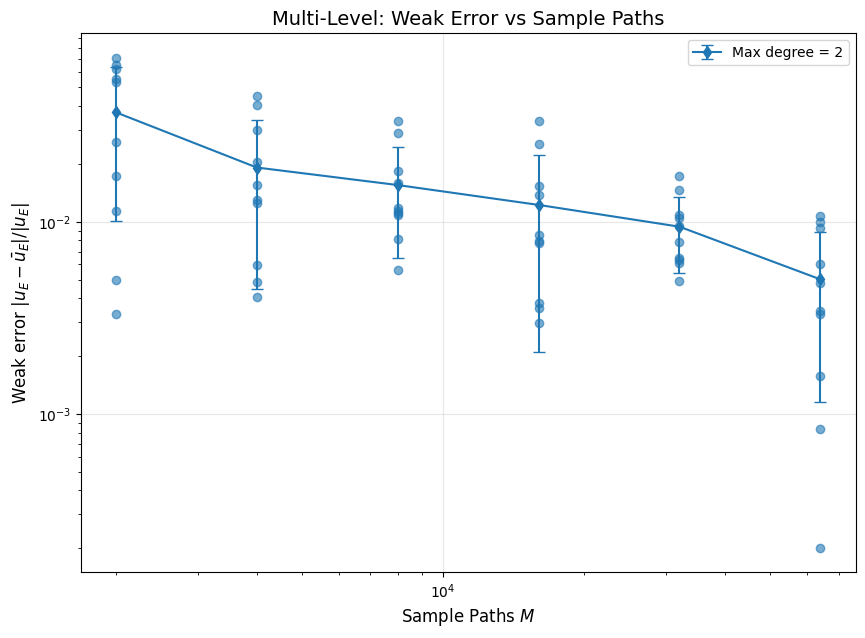

In [6]:
# Step 5: weak error validation for the multi-level fitted surface

# Validation grid
dt_val = h0 * 2**(-max_deg)
N_t_val = int(T / dt_val)

M_samples = [2000, 4000, 8000, 16000, 32000, 64000]
trials = 10

# Compute weak errors for current fitted b_bar_ml
weak_errors_ml = compute_weak_error_ML(
    b_bar=b_bar_ml,
    x0=x0,
    P1=P1,
    vol=vol,
    cov_mat=cov_mat,
    r=r,
    dt=dt_val,
    N_t=N_t_val,
    M_samples=M_samples,
    trials=trials
)

print("\n--- Step 5 summary (single degree) ---")
print("weak_errors_ml shape:", weak_errors_ml.shape)
print("mean weak error by M:", np.mean(weak_errors_ml, axis=1))
print("std weak error by M:", np.std(weak_errors_ml, axis=1, ddof=1))

# Plot in the function's expected dictionary format
weak_errors_dict = {max_deg: weak_errors_ml}
max_deg_test = [max_deg]

fig, ax = plot_weak_error_convergence(
    M_samples=M_samples,
    weak_errors_dict=weak_errors_dict,
    max_deg_test=max_deg_test,
    save_path='weakerror_ML_maxd3.pdf'
)

plt.show()

29.5165500225381
30.3233746910898
31.09448205663255


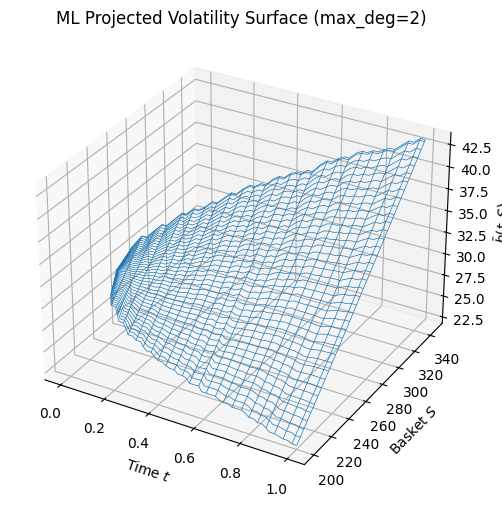

basket0 shape: (10000, 32)
len(t_plot): 32


In [7]:


print(b_bar_ml(0.0, np.mean(basket0[:, 0])))
print(b_bar_ml(T/2, np.mean(basket0[:, basket0.shape[1]//2])))
print(b_bar_ml(T, np.mean(basket0[:, -1])))

dt_plot = h0 * 2**(-max_deg)
N_t_plot = int(T / dt_plot)
t_plot = np.linspace(0, T, N_t_plot)
fig, ax = plot_local_volatility(
    b_bar=b_bar_ml,
    basket=basket0,
    t=t_plot,
    K=50,
    L=150,
    title=f"ML Projected Volatility Surface (max_deg={max_deg})",
    color="C0",
    save_path='MLsurfmd3.pdf',  # or e.g. "ML_VolSurf_maxdeg3.pdf"
)
plt.show()
print("basket0 shape:", basket0.shape)
print("len(t_plot):", len(t_plot))